In [18]:
import pandas as pd

# Load Excel
df = pd.read_excel("heart_disease.xlsx", sheet_name='Heart_disease')
print(df.info())
print(df.describe())
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB
None
              age    trestbps        chol      thalch     oldpeak         num
count  908.000000  908.000000  908.000000  908.000000  846.000000  908.000000
mean    53.791850  133.430617  201.484581  135.957048    0.891253    1.008811

In [21]:
df['oldpeak'].fillna(df['oldpeak'].median(), inplace=True)


/tmp/ipython-input-21-536765289.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['oldpeak'].fillna(df['oldpeak'].median(), inplace=True)


In [22]:
from sklearn.preprocessing import LabelEncoder

label_cols = ['sex', 'cp', 'restecg', 'slope', 'thal', 'exang']
le_dict = {}

for col in label_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le  # save encoder for inverse transform if needed


In [24]:
# Create a binary target: 1 if any heart disease, 0 otherwise
df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)


In [25]:
X = df.drop(columns=['num', 'target'])  # Drop original and target
y = df['target']


In [26]:
from sklearn.model_selection import train_test_split

# 80-20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [27]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Instantiate and train
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

# Predict on test set
y_pred = clf.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.7197802197802198
[[58 22]
 [29 73]]
              precision    recall  f1-score   support

           0       0.67      0.72      0.69        80
           1       0.77      0.72      0.74       102

    accuracy                           0.72       182
   macro avg       0.72      0.72      0.72       182
weighted avg       0.72      0.72      0.72       182



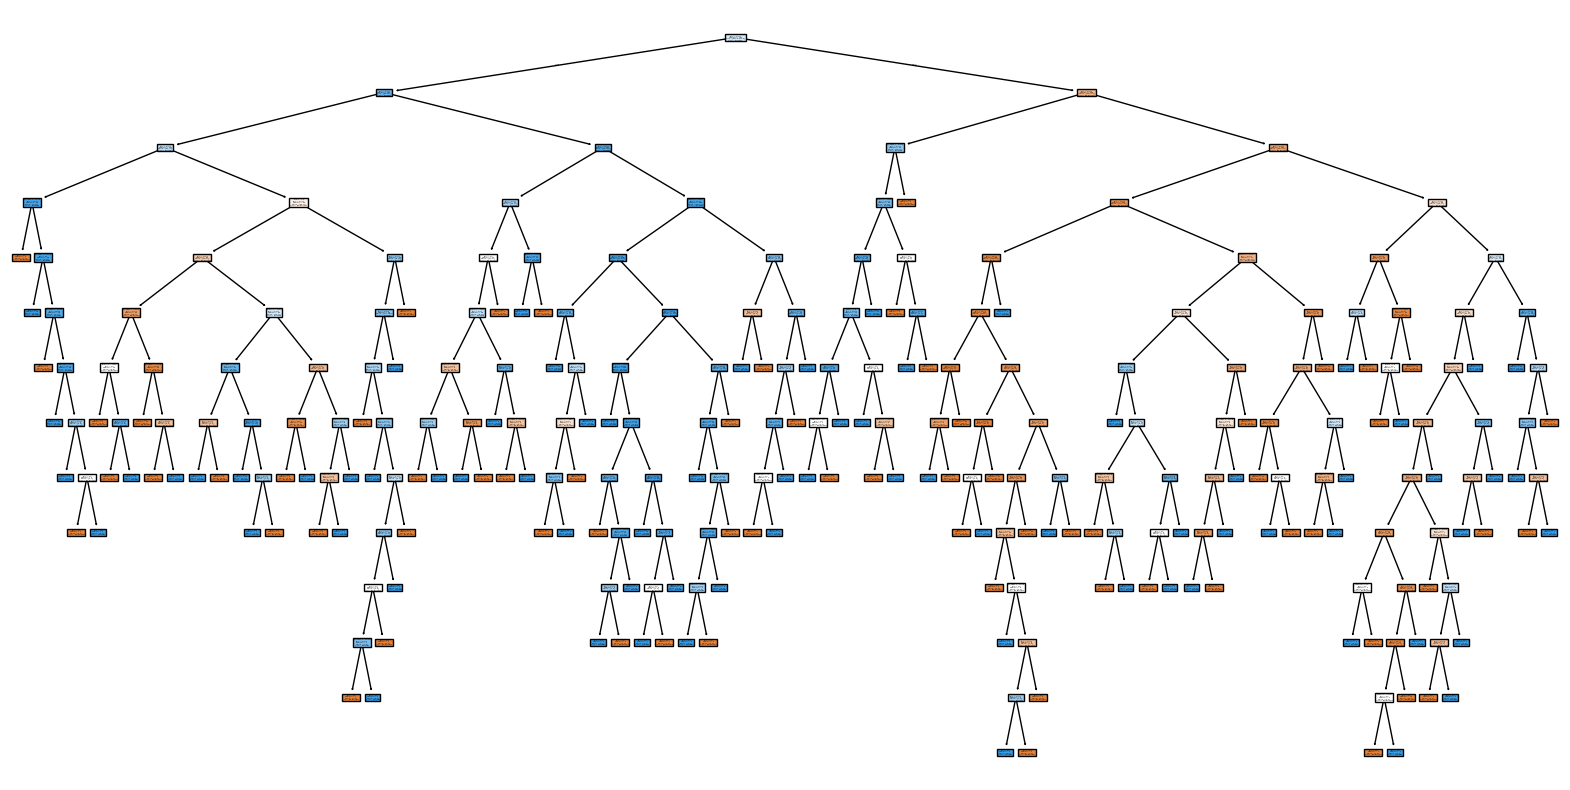

In [28]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(clf, feature_names=X.columns, class_names=['No Disease', 'Disease'], filled=True)
plt.show()


In [29]:
from sklearn.model_selection import GridSearchCV

# Define hyperparameter grid
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# Grid search with 5-fold CV
grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

# Re-evaluate using the best estimator
best_model = grid.best_estimator_
y_best_pred = best_model.predict(X_test)

print("Tuned Accuracy:", accuracy_score(y_test, y_best_pred))
print(classification_report(y_test, y_best_pred))


Best Parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 5}
Tuned Accuracy: 0.7197802197802198
              precision    recall  f1-score   support

           0       0.67      0.71      0.69        80
           1       0.76      0.73      0.74       102

    accuracy                           0.72       182
   macro avg       0.72      0.72      0.72       182
weighted avg       0.72      0.72      0.72       182



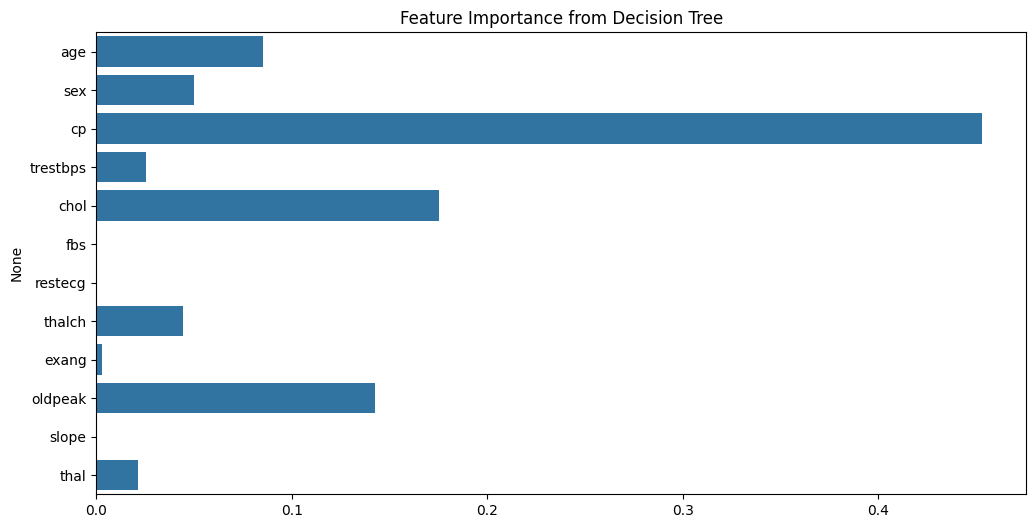

In [30]:
import seaborn as sns

importances = best_model.feature_importances_
features = X.columns

# Plot
plt.figure(figsize=(12,6))
sns.barplot(x=importances, y=features)
plt.title("Feature Importance from Decision Tree")
plt.show()


Q1. What are some common hyperparameters of Decision Tree models, and how do they affect the model's performance?

1.max_depth:

It sets the maximum depth of the tree.

A deeper tree can capture more patterns but may overfit the data. Limiting depth helps reduce overfitting.

2.min_samples_split:

The minimum number of samples required to split an internal node.

A higher value makes the tree more conservative and avoids overfitting.

3.min_samples_leaf:

The minimum number of samples that must be present in a leaf node.

Helps prevent the model from learning noisy patterns in the data.

4.criterion:

It defines the function used to measure the quality of a split. Common options are 'gini' and 'entropy'.

'gini' is faster and typically preferred, while 'entropy' gives information gain but is computationally heavier.

5.max_features:

Limits the number of features to consider when looking for the best split.

Reducing it can prevent overfitting and increase model generalization.

6.splitter:

Decides the strategy used to choose the split at each node.

'best' chooses the best split, while 'random' selects the best among random splits, useful in randomized trees.

➡️ Tuning these hyperparameters helps control the bias-variance trade-off, ensuring the model performs well on both training and unseen data.




Q2. What is the difference between Label Encoding and One-Hot Encoding?


Answer:

Label Encoding and One-Hot Encoding are two techniques used to convert categorical data into numerical format so that machine learning algorithms can understand it.

🔹 Label Encoding:
It assigns a unique integer value to each category.

For example, ['Red', 'Green', 'Blue'] becomes [0, 1, 2].

This method is best suited for ordinal data, where the categories have a meaningful order (e.g., Low, Medium, High).

Pros:

Simple and memory efficient.

Keeps the data compact.

Cons:

May introduce unintended ordinal relationships between categories.
For instance, the model might interpret 2 > 1 > 0 as a ranked order when there isn’t one.

🔹 One-Hot Encoding:
It creates a new binary column for each category.

For example, ['Red', 'Green', 'Blue'] becomes:

Red → [1, 0, 0]

Green → [0, 1, 0]

Blue → [0, 0, 1]

This method is best suited for nominal data, where the categories do not have any order.

Pros:

Avoids introducing false ordinal relationships.

Preserves categorical meaning correctly.

Cons:

Increases the dimensionality of the dataset, especially when the number of categories is large.

